# Accessible Heatmaps in R

This notebook is a standalone teaching resource for creating accessible heatmaps with **ggplot2** in R.

## What this graph is used for

Heatmaps represent matrix values, correlations, intensity or magnitude, and other structured comparisons.

## How to make it more accessible

Use a colorblind-friendly palette, label rows and columns with semantic names, add a descriptive title, and provide a labeled color scale explaining what the colors encode. Readable tick labels and careful rotation can also improve interpretation.

## Setup

This notebook uses **ggplot2**, the plotting library used throughout the supplied R teaching materials.

If `ggplot2` is not installed in your R environment, install it once with:

```r
install.packages("ggplot2")
```

Then load it with `library(ggplot2)`.

The Python notebooks use MatplotAlt to generate four levels of alternative-text description automatically. MatplotAlt is Python-specific, so the R notebooks keep the same teaching structure but provide the four description levels as Markdown text. For the reusable template, a four-level description template is provided for you to adapt to your own data.


In [1]:
library(ggplot2)

## Accessible example

The code below showcases an accessibility-aware example of a heatmap created in R. It uses `geom_tile()` and ggplot2's cividis option.

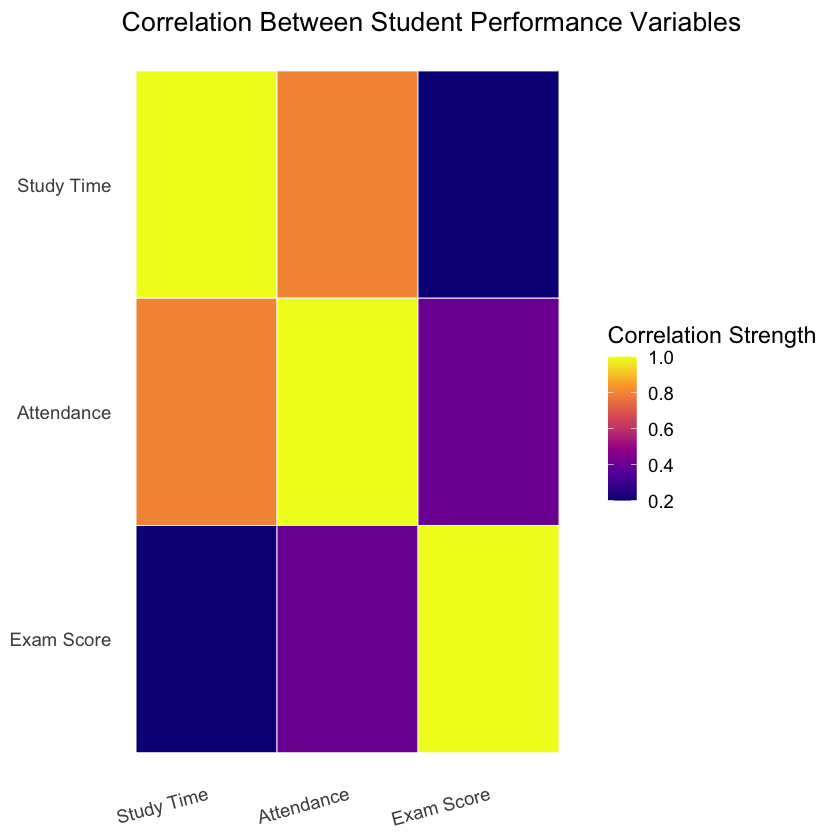

In [2]:
correlation_matrix <- matrix(
  c(
    1.0, 0.8, 0.2,
    0.8, 1.0, 0.4,
    0.2, 0.4, 1.0
  ),
  nrow = 3,
  byrow = TRUE
)

feature_names <- c("Study Time", "Attendance", "Exam Score")

heatmap_data <- expand.grid(
  row_index = 1:3,
  column_index = 1:3
)

heatmap_data$value <- as.vector(t(correlation_matrix))
heatmap_data$row <- feature_names[heatmap_data$row_index]
heatmap_data$column <- feature_names[heatmap_data$column_index]

heatmap_data$row <- factor(
  heatmap_data$row,
  levels = rev(feature_names)
)

heatmap_data$column <- factor(
  heatmap_data$column,
  levels = feature_names
)

ggplot(
  heatmap_data,
  aes(x = column, y = row, fill = value)
) +
  geom_tile(color = "white") +
  scale_fill_viridis_c(
    option = "C",
    name = "Correlation Strength",
    limits = c(0.2, 1.0)
  ) +
  labs(
    title = "Correlation Between Student Performance Variables",
    x = NULL,
    y = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(size = 16),
    axis.text.x = element_text(angle = 15, hjust = 1),
    panel.grid = element_blank()
  )

## Reusable accessible template

Replace the placeholder matrix, names, and labels below with your own values. Keep semantic row and column labels, a descriptive title, a labeled color scale, a colorblind-friendly palette, and readable text.

In [ ]:
# Replace the placeholder matrix, names, and text below with your own values.
matrix_values <- matrix(
  c(
    1.0, 0.6, 0.3,
    0.6, 1.0, 0.5,
    0.3, 0.5, 1.0
  ),
  nrow = 3,
  byrow = TRUE
)

row_and_column_names <- c("Variable A", "Variable B", "Variable C")
graph_title <- "Descriptive title for the matrix relationship"
colorbar_label <- "Magnitude or relationship strength"

template_heatmap_data <- expand.grid(
  row_index = seq_along(row_and_column_names),
  column_index = seq_along(row_and_column_names)
)

template_heatmap_data$value <- as.vector(t(matrix_values))
template_heatmap_data$row <- row_and_column_names[template_heatmap_data$row_index]
template_heatmap_data$column <- row_and_column_names[template_heatmap_data$column_index]

template_heatmap_data$row <- factor(
  template_heatmap_data$row,
  levels = rev(row_and_column_names)
)

template_heatmap_data$column <- factor(
  template_heatmap_data$column,
  levels = row_and_column_names
)

ggplot(
  template_heatmap_data,
  aes(x = column, y = row, fill = value)
) +
  geom_tile(color = "white") +
  scale_fill_viridis_c(
    option = "C",
    name = colorbar_label
  ) +
  labs(
    title = graph_title,
    x = NULL,
    y = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(size = 16),
    axis.text.x = element_text(angle = 15, hjust = 1),
    panel.grid = element_blank()
  )

### Four-level description template for your graph

After replacing the placeholder data, update the descriptions below so that they match the graph you generated.

**Level 1 — chart structure and encodings**

State the chart type, title, axes or categories, units, and the visual encodings used.

**Level 2 — data/statistical detail**

Summarize important values, ranges, minima/maxima, counts, quartiles, or other relevant statistics.

**Level 3 — trends or relationships**

Describe the main trend, association, distribution pattern, clustering, or comparison shown by the graph.

**Level 4 — broader interpretation**

Explain the main contextual takeaway of the graph without adding claims that are not supported by the plotted data.
